In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml
from scipy.stats import norm

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 140)
plt.style.use("seaborn-v0_8-whitegrid")


def find_repo_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / "src").exists() and (candidate / "config" / "model_config.yaml").exists():
            return candidate
    raise RuntimeError("Could not locate repository root")


ROOT = find_repo_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.distribution_pricing import price_buckets_for_dataframe
from src.evaluation import (
    bucket_brier_scores,
    interval_log_loss,
    prediction_interval_coverage,
    validate_bucket_probabilities,
)

PATHS = {
    "config": ROOT / "config" / "model_config.yaml",
    "features": ROOT / "outputs" / "feature_lists" / "current36_plus_gap_rate_quick.json",
    "model_features": ROOT / "models" / "ngboost_normal_current36_plus_gap_quick_features.json",
    "modeling": ROOT / "data" / "processed" / "modeling_rows_v1.csv",
    "daily": ROOT / "data" / "processed" / "daily_clean.csv",
    "hourly": ROOT / "data" / "processed" / "hourly_clean.csv",
    "forecasts": ROOT / "data" / "processed" / "forecasts_clean.csv",
    "targets": ROOT / "data" / "processed" / "supervised_forecast_error_rows.csv",
    "params": ROOT / "outputs" / "ngboost_distribution_params_current36_plus_gap_quick.csv",
    "metrics": ROOT / "outputs" / "ngboost_nll_current36_plus_gap_quick.json",
    "summary": ROOT / "outputs" / "ngboost_current36_plus_gap_quick_summary.json",
}

missing = [name for name, path in PATHS.items() if not path.exists()]
assert not missing, f"Missing required notebook inputs: {missing}"

with PATHS["config"].open("r", encoding="utf-8") as handle:
    config = yaml.safe_load(handle)
with PATHS["features"].open("r", encoding="utf-8") as handle:
    feature_spec = json.load(handle)
with PATHS["model_features"].open("r", encoding="utf-8") as handle:
    model_feature_spec = json.load(handle)
with PATHS["metrics"].open("r", encoding="utf-8") as handle:
    candidate_metrics = json.load(handle)
with PATHS["summary"].open("r", encoding="utf-8") as handle:
    candidate_summary = json.load(handle)

modeling = pd.read_csv(PATHS["modeling"], parse_dates=["date", "prediction_time"], low_memory=False)
params = pd.read_csv(PATHS["params"], parse_dates=["date", "prediction_time"], low_memory=False)
standard_config = config["ngboost"]["standard_training"]
feature_count = int(feature_spec.get("feature_count", len(feature_spec["features"])))
model_display_name = "37-feature gap-rate Normal NGBoost"
model_artifact_name = "ngboost_normal_current36_plus_gap_quick"


def count_csv_rows(path):
    return int(pd.read_csv(path, usecols=[0]).shape[0])


def bucket_probability_frame_and_labels(long: pd.DataFrame, prediction_frame: pd.DataFrame):
    working = long.copy()
    working["market_bucket"] = "market_bucket_" + working["bucket_index"].astype(int).astype(str)
    actual = pd.to_numeric(working["actual_high"], errors="raise")
    lower = pd.to_numeric(working["bucket_lower_temp"], errors="coerce")
    upper = pd.to_numeric(working["bucket_upper_temp"], errors="coerce")
    in_bucket = (lower.isna() | (actual > lower)) & (upper.isna() | (actual <= upper))
    labels = working[in_bucket][["row_id", "market_bucket"]]
    if labels.duplicated("row_id").any():
        raise ValueError("A row matched multiple realized buckets")

    expected = pd.Index(pd.to_numeric(prediction_frame["row_id"], errors="raise").astype(int))
    labels = labels.set_index("row_id")["market_bucket"].reindex(expected)
    if labels.isna().any():
        raise ValueError("Some rows did not match a realized bucket")

    probs = working.pivot(index="row_id", columns="market_bucket", values="probability")
    ordered_columns = [
        f"market_bucket_{bucket_index}"
        for bucket_index in sorted(working["bucket_index"].astype(int).unique())
    ]
    probs = probs[ordered_columns].reindex(expected)
    if probs.isna().any().any():
        raise ValueError("Bucket probability frame has missing values")
    probs = validate_bucket_probabilities(probs.astype(float), allow_renormalize=False)
    return probs.reset_index(drop=True), labels.reset_index(drop=True)


def score_bucket_metrics(long: pd.DataFrame, prediction_frame: pd.DataFrame) -> dict:
    probs, labels = bucket_probability_frame_and_labels(long, prediction_frame)
    brier = bucket_brier_scores(probs, labels)
    return {
        "bucket_log_loss": float(interval_log_loss(probs, labels)),
        "mean_bucket_brier": float(brier["brier_score"].mean()),
    }


def build_reliability_table(long: pd.DataFrame, bins=6) -> pd.DataFrame:
    working = long.copy()
    working["bucket"] = "market_bucket_" + working["bucket_index"].astype(int).astype(str)
    actual = pd.to_numeric(working["actual_high"], errors="raise")
    lower = pd.to_numeric(working["bucket_lower_temp"], errors="coerce")
    upper = pd.to_numeric(working["bucket_upper_temp"], errors="coerce")
    working["outcome"] = ((lower.isna() | (actual > lower)) & (upper.isna() | (actual <= upper))).astype(float)
    working["probability_bin"] = pd.cut(
        working["probability"],
        bins=np.linspace(0, 1, bins + 1),
        include_lowest=True,
    )
    return (
        working.groupby(["split", "bucket", "probability_bin"], observed=True)
        .agg(
            mean_predicted_probability=("probability", "mean"),
            empirical_frequency=("outcome", "mean"),
            count=("outcome", "size"),
        )
        .reset_index()
    )


bucket_probs = price_buckets_for_dataframe(params, dist_type="normal")

metric_rows = []
coverage_rows = []
for split_name in ["validation", "test"]:
    split_params = params[params["split"] == split_name].copy()
    split_buckets = bucket_probs[bucket_probs["split"] == split_name].copy()
    bucket_scores = score_bucket_metrics(split_buckets, split_params)
    metric_rows.append(
        {
            "model": model_display_name,
            "split": split_name,
            "nll": float(split_params["nll"].mean()),
            **bucket_scores,
        }
    )
    split_coverage = prediction_interval_coverage(
        split_params["forecast_error"],
        split_params["mu"],
        split_params["sigma"],
        levels=(0.5, 0.8, 0.9),
        dist_type="normal",
    )
    split_coverage.insert(0, "split", split_name)
    coverage_rows.append(split_coverage)

model_metrics = pd.DataFrame(metric_rows)
coverage = pd.concat(coverage_rows, ignore_index=True)
reliability = build_reliability_table(bucket_probs)

train_errors = modeling[pd.to_datetime(modeling["date"]) < "2024-01-01"]["forecast_error"].astype(float)
train_mu = float(train_errors.mean())
train_sigma = float(train_errors.std(ddof=1))

test_params = params[params["split"] == "test"].copy()
baseline_params = test_params.copy()
baseline_params["mu"] = train_mu
baseline_params["sigma"] = train_sigma
baseline_params["distribution_type"] = "normal"
baseline_params["nll"] = -norm.logpdf(
    baseline_params["forecast_error"],
    loc=train_mu,
    scale=train_sigma,
)
baseline_buckets = price_buckets_for_dataframe(baseline_params, dist_type="normal")
baseline_bucket_scores = score_bucket_metrics(baseline_buckets, baseline_params)


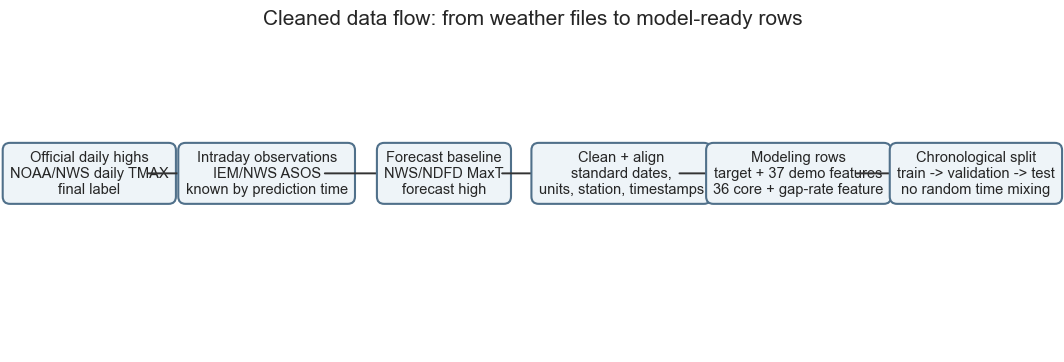

In [2]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.axis("off")

steps = [
    ("Official daily highs", "NOAA/NWS daily TMAX\nfinal label"),
    ("Intraday observations", "IEM/NWS ASOS\nknown by prediction time"),
    ("Forecast baseline", "NWS/NDFD MaxT\nforecast high"),
    ("Clean + align", "standard dates,\nunits, station, timestamps"),
    ("Modeling rows", "target + 37 demo features\n36 core + gap-rate feature"),
    ("Chronological split", "train -> validation -> test\nno random time mixing"),
]

xs = np.linspace(0.06, 0.94, len(steps))
for i, ((title, body), x) in enumerate(zip(steps, xs)):
    ax.text(
        x,
        0.58,
        f"{title}\n{body}",
        ha="center",
        va="center",
        fontsize=10.5,
        bbox=dict(boxstyle="round,pad=0.5", facecolor="#eef4f8", edgecolor="#50708a", linewidth=1.5),
        transform=ax.transAxes,
    )
    if i < len(steps) - 1:
        ax.annotate(
            "",
            xy=(xs[i + 1] - 0.055, 0.58),
            xytext=(x + 0.055, 0.58),
            arrowprops=dict(arrowstyle="->", color="#333333", lw=1.4),
            xycoords=ax.transAxes,
            textcoords=ax.transAxes,
        )

ax.set_title("Cleaned data flow: from weather files to model-ready rows", fontsize=15, pad=14)
plt.show()


,stage,main_file,rows
0,Clean daily actual highs,daily_clean.csv,"1,615"
1,Clean hourly observations,hourly_clean.csv,"48,462"
2,Clean forecast highs,forecasts_clean.csv,"38,424"
3,Forecast-error target rows,supervised_forecast_error_rows.csv,"38,424"
4,Final model-ready rows,modeling_rows_v1.csv,"36,797"


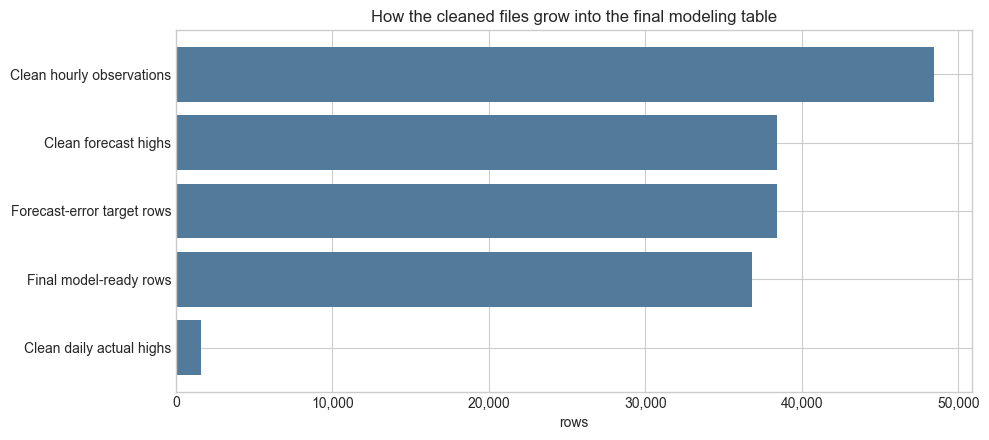

In [3]:
table_counts = pd.DataFrame(
    [
        {"stage": "Clean daily actual highs", "main_file": "daily_clean.csv", "rows": count_csv_rows(PATHS["daily"])},
        {"stage": "Clean hourly observations", "main_file": "hourly_clean.csv", "rows": count_csv_rows(PATHS["hourly"])},
        {"stage": "Clean forecast highs", "main_file": "forecasts_clean.csv", "rows": count_csv_rows(PATHS["forecasts"])},
        {"stage": "Forecast-error target rows", "main_file": "supervised_forecast_error_rows.csv", "rows": count_csv_rows(PATHS["targets"])},
        {"stage": "Final model-ready rows", "main_file": "modeling_rows_v1.csv", "rows": len(modeling)},
    ]
)

display(table_counts.style.format({"rows": "{:,}"}))

fig, ax = plt.subplots(figsize=(10, 4.5))
plot_counts = table_counts.sort_values("rows")
ax.barh(plot_counts["stage"], plot_counts["rows"], color="#527a9a")
ax.set_xlabel("rows")
ax.set_title("How the cleaned files grow into the final modeling table")
ax.xaxis.set_major_formatter(lambda x, pos: f"{int(x):,}")
plt.tight_layout()
plt.show()


In [4]:
source_summary = pd.DataFrame(
    [
        {
            "model input": "Actual daily high",
            "source used": "NOAA/NWS daily TMAX",
            "why it is used": "Official final label for the day.",
        },
        {
            "model input": "Intraday weather so far",
            "source used": "IEM/NWS ASOS observations",
            "why it is used": "Station observations available during the day.",
        },
        {
            "model input": "Forecast high baseline",
            "source used": "NWS/NDFD historical MaxT",
            "why it is used": "Timestamp-safe forecast issued before prediction time.",
        },
        {
            "model input": "Gap-rate feature",
            "source used": "Forecast high + current observed temp + clock time",
            "why it is used": "Measures how fast the day must still warm to reach the forecast high by the usual peak time.",
        },
    ]
)
display(source_summary)

target_delta = (modeling["actual_high"] - modeling["forecast_high"] - modeling["forecast_error"]).abs()
date_min = modeling["date"].min().date()
date_max = modeling["date"].max().date()

checks = pd.DataFrame(
    [
        {"check": "Date coverage", "result": f"{date_min} to {date_max}"},
        {"check": "Final modeling rows", "result": f"{len(modeling):,}"},
        {"check": "Demo model feature count", "result": f"{feature_count} numeric features"},
        {"check": "Missing target values", "result": f"{int(modeling['forecast_error'].isna().sum()):,}"},
        {"check": "Target formula check", "result": f"max difference = {target_delta.max():.6g}"},
    ]
)
display(checks)


,model input,source used,why it is used
0,Actual daily high,NOAA/NWS daily TMAX,Official final label for the day.
1,Intraday weather so far,IEM/NWS ASOS observations,Station observations available during the day.
2,Forecast high baseline,NWS/NDFD historical MaxT,Timestamp-safe forecast issued before predicti...
3,Gap-rate feature,Forecast high + current observed temp + clock ...,Measures how fast the day must still warm to r...


,check,result
0,Date coverage,2022-01-01 to 2026-05-20
1,Final modeling rows,"36,797"
2,Demo model feature count,37 numeric features
3,Missing target values,0
4,Target formula check,max difference = 4.37996e-11


,split,rows,start,end
0,Train,"16,791",2022-01-01,2023-12-31
1,Validation,"8,396",2024-01-01,2024-12-31
2,Test,"11,610",2025-01-01,2026-05-20


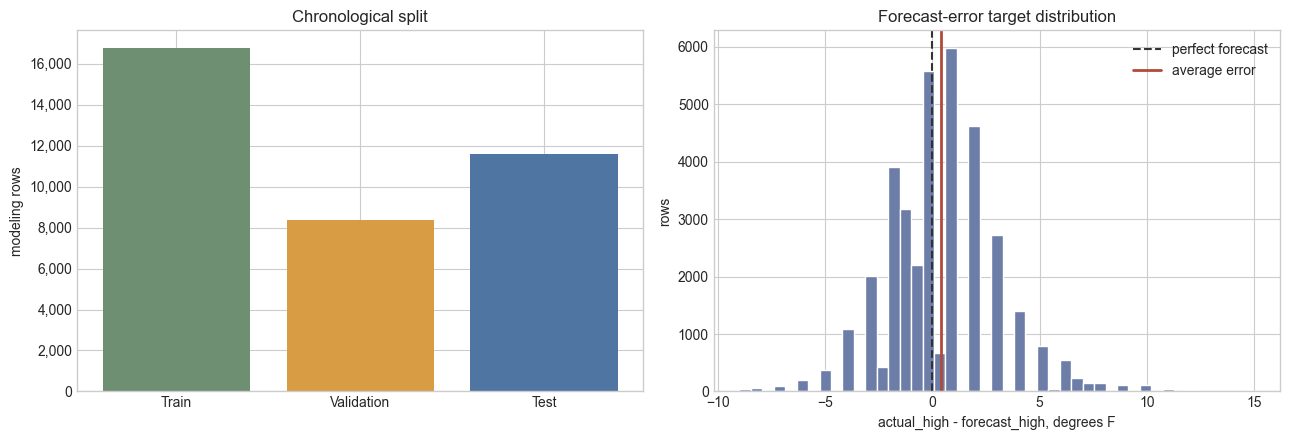

In [5]:
split_dates = pd.to_datetime(modeling["date"])
split_labels = np.select(
    [split_dates < "2024-01-01", (split_dates >= "2024-01-01") & (split_dates < "2025-01-01"), split_dates >= "2025-01-01"],
    ["Train", "Validation", "Test"],
    default="Other",
)
split_table = (
    pd.DataFrame({"split": split_labels, "date": split_dates})
    .groupby("split")
    .agg(rows=("date", "size"), start=("date", "min"), end=("date", "max"))
    .loc[["Train", "Validation", "Test"]]
    .reset_index()
)
split_table["start"] = split_table["start"].dt.date
split_table["end"] = split_table["end"].dt.date
display(split_table.style.format({"rows": "{:,}"}))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].bar(split_table["split"], split_table["rows"], color=["#6f8f72", "#d89c45", "#4f75a3"])
axes[0].set_title("Chronological split")
axes[0].set_ylabel("modeling rows")
axes[0].yaxis.set_major_formatter(lambda x, pos: f"{int(x):,}")

axes[1].hist(modeling["forecast_error"], bins=45, color="#6c7ea8", edgecolor="white")
axes[1].axvline(0, color="#333333", linestyle="--", linewidth=1.5, label="perfect forecast")
axes[1].axvline(modeling["forecast_error"].mean(), color="#b24a3b", linewidth=2, label="average error")
axes[1].set_title("Forecast-error target distribution")
axes[1].set_xlabel("actual_high - forecast_high, degrees F")
axes[1].set_ylabel("rows")
axes[1].legend()

plt.tight_layout()
plt.show()


In [6]:
gap_feature = "forecast_current_temp_gap_per_hour_to_peak"
model_summary = pd.DataFrame(
    [
        {"item": "Specific model shown", "value": model_artifact_name},
        {"item": "Model family", "value": "Normal NGBoost distributional regression"},
        {"item": "Prediction target", "value": "forecast_error = actual_high - forecast_high"},
        {"item": "Output parameters", "value": "mu = expected forecast error; sigma = uncertainty"},
        {"item": "Feature contract", "value": f"{feature_spec['version']} ({feature_count} features)"},
        {"item": "Added trading feature", "value": f"{gap_feature}: required warming per hour until the usual high-temperature time"},
        {
            "item": "Core settings",
            "value": (
                f"depth {standard_config['max_depth']} trees, "
                f"leaf {standard_config['min_samples_leaf']}, "
                f"{standard_config['n_estimators']} estimators, "
                f"learning rate {standard_config['learning_rate']}"
            ),
        },
        {"item": "Why this one is shown", "value": "Chosen for the demo because it improves bucket-market Brier and test bucket log loss."},
    ]
)
display(model_summary)

param_summary = (
    params.groupby("split")
    .agg(
        rows=("row_id", "count"),
        avg_mu=("mu", "mean"),
        avg_sigma=("sigma", "mean"),
        avg_nll=("nll", "mean"),
        first_date=("date", "min"),
        last_date=("date", "max"),
    )
    .reset_index()
)
display(param_summary.style.format({"rows": "{:,}", "avg_mu": "{:.3f}", "avg_sigma": "{:.3f}", "avg_nll": "{:.3f}"}))


,item,value
0,Specific model shown,ngboost_normal_current36_plus_gap_quick
1,Model family,Normal NGBoost distributional regression
2,Prediction target,forecast_error = actual_high - forecast_high
3,Output parameters,mu = expected forecast error; sigma = uncertainty
4,Feature contract,official_migration_current36_plus_gap_rate_qui...
5,Added trading feature,forecast_current_temp_gap_per_hour_to_peak: re...
6,Core settings,"depth 3 trees, leaf 50, 500 estimators, learni..."
7,Why this one is shown,Chosen for the demo because it improves bucket...


,split,rows,avg_mu,avg_sigma,avg_nll,first_date,last_date
0,test,"11,610",0.479,1.513,1.722,2025-01-01 00:00:00,2026-05-20 00:00:00
1,validation,"8,396",0.327,1.510,1.820,2024-01-01 00:00:00,2024-12-31 00:00:00


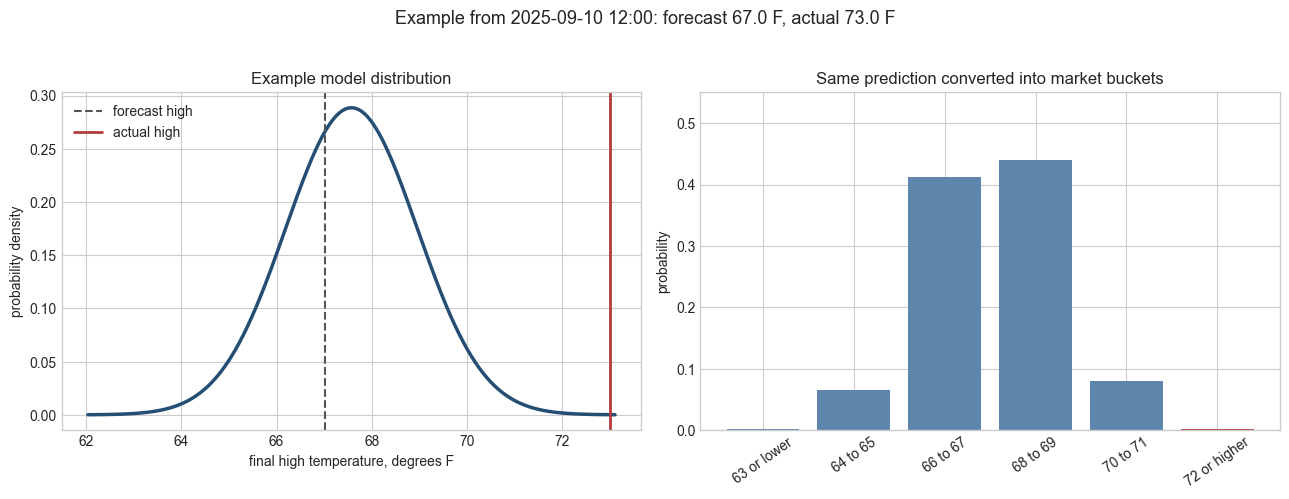

,temperature bucket,model probability,actual landed here
85200,63 or lower,0.2%,False
85201,64 to 65,6.5%,False
85202,66 to 67,41.2%,False
85203,68 to 69,43.9%,False
85204,70 to 71,7.9%,False
85205,72 or higher,0.2%,True


In [7]:
params_midday = params.assign(hour=params["prediction_time"].dt.hour)
example_pool = params_midday[(params_midday["split"] == "test") & (params_midday["hour"].between(11, 15))]
if example_pool.empty:
    example_pool = params_midday[params_midday["split"] == "test"]

example = example_pool.sort_values("prediction_time").iloc[len(example_pool) // 2]
example_id = int(example["row_id"])
example_split = example["split"]
example_buckets = bucket_probs[(bucket_probs["row_id"] == example_id) & (bucket_probs["split"] == example_split)].copy()
actual_high = float(example["actual_high"])
example_buckets["realized"] = example_buckets.apply(
    lambda r: (pd.isna(r["bucket_lower_temp"]) or actual_high > r["bucket_lower_temp"])
    and (pd.isna(r["bucket_upper_temp"]) or actual_high <= r["bucket_upper_temp"]),
    axis=1,
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

x_error = np.linspace(float(example["mu"]) - 4 * float(example["sigma"]), float(example["mu"]) + 4 * float(example["sigma"]), 500)
x_temp = float(example["forecast_high"]) + x_error
density = norm.pdf(x_error, loc=float(example["mu"]), scale=float(example["sigma"]))
axes[0].plot(x_temp, density, color="#244e73", linewidth=2.5)
axes[0].axvline(float(example["forecast_high"]), color="#555555", linestyle="--", label="forecast high")
axes[0].axvline(actual_high, color="#b23b3b", linewidth=2, label="actual high")
axes[0].set_title("Example model distribution")
axes[0].set_xlabel("final high temperature, degrees F")
axes[0].set_ylabel("probability density")
axes[0].legend()

bar_colors = np.where(example_buckets["realized"], "#b23b3b", "#5e86ad")
axes[1].bar(example_buckets["bucket_name"], example_buckets["probability"], color=bar_colors)
axes[1].set_title("Same prediction converted into market buckets")
axes[1].set_ylabel("probability")
axes[1].tick_params(axis="x", rotation=35)
axes[1].set_ylim(0, max(0.55, example_buckets["probability"].max() * 1.2))

fig.suptitle(
    f"Example from {pd.to_datetime(example['prediction_time']).strftime('%Y-%m-%d %H:%M')}: "
    f"forecast {float(example['forecast_high']):.1f} F, actual {actual_high:.1f} F",
    y=1.03,
    fontsize=13,
)
plt.tight_layout()
plt.show()

display(
    example_buckets[["bucket_name", "probability", "realized"]]
    .rename(columns={"bucket_name": "temperature bucket", "probability": "model probability", "realized": "actual landed here"})
    .style.format({"model probability": "{:.1%}"})
)


,metric,what it means,model_value,baseline,baseline_value,improvement_vs_baseline
0,NLL,full-distribution accuracy,1.722,Simple historical Normal,2.368,27.3%
1,Bucket log loss,probability on the market bucket that happened,1.038,Simple historical Normal,1.594,34.9%
2,Mean bucket Brier,bucket probability accuracy,0.092,Simple historical Normal,0.128,28.1%


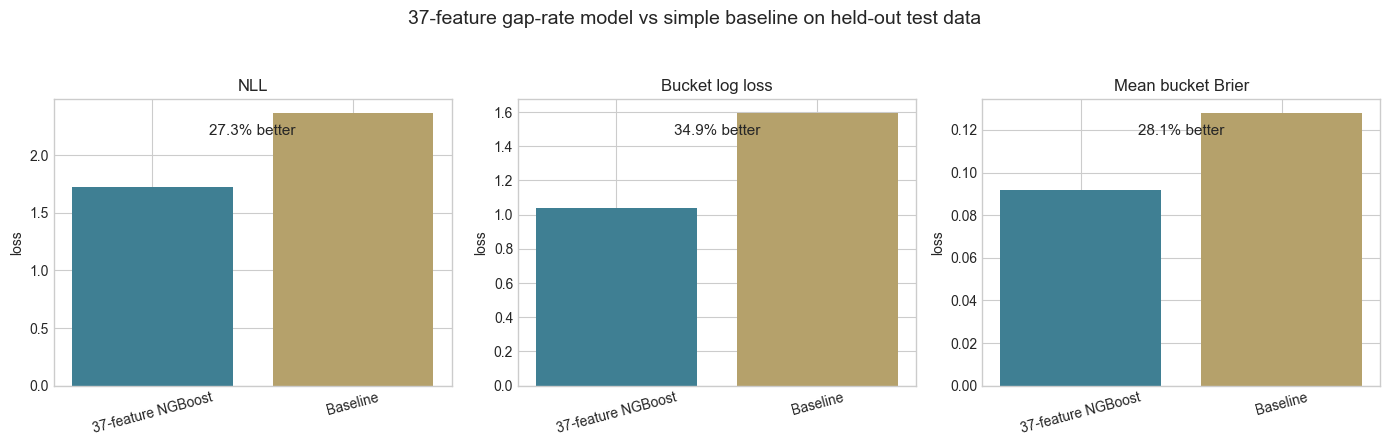

,model,split,feature_count,nll,bucket_log_loss,mean_bucket_brier,coverage_80,coverage_90
0,current_main_normal36,validation,36,1.756,1.089,0.120,85.4%,92.5%
1,current_main_normal36,test,36,1.687,1.069,0.117,88.4%,94.2%
2,normal_current36_plus_gap_quick,validation,37,1.820,1.134,0.098,80.5%,89.2%
3,normal_current36_plus_gap_quick,test,37,1.722,1.038,0.092,83.6%,91.8%


In [8]:
model_test = model_metrics[model_metrics["split"] == "test"].iloc[0]
baseline_test_nll = float(baseline_params["nll"].mean())

metric_rows = pd.DataFrame(
    [
        {
            "metric": "NLL",
            "what it means": "full-distribution accuracy",
            "model_value": float(model_test["nll"]),
            "baseline": "Simple historical Normal",
            "baseline_value": baseline_test_nll,
        },
        {
            "metric": "Bucket log loss",
            "what it means": "probability on the market bucket that happened",
            "model_value": float(model_test["bucket_log_loss"]),
            "baseline": "Simple historical Normal",
            "baseline_value": float(baseline_bucket_scores["bucket_log_loss"]),
        },
        {
            "metric": "Mean bucket Brier",
            "what it means": "bucket probability accuracy",
            "model_value": float(model_test["mean_bucket_brier"]),
            "baseline": "Simple historical Normal",
            "baseline_value": float(baseline_bucket_scores["mean_bucket_brier"]),
        },
    ]
)
metric_rows["improvement_vs_baseline"] = (metric_rows["baseline_value"] - metric_rows["model_value"]) / metric_rows["baseline_value"]

display(
    metric_rows[
        ["metric", "what it means", "model_value", "baseline", "baseline_value", "improvement_vs_baseline"]
    ].style.format(
        {
            "model_value": "{:.3f}",
            "baseline_value": "{:.3f}",
            "improvement_vs_baseline": "{:.1%}",
        }
    )
)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
for ax, (_, row) in zip(axes, metric_rows.iterrows()):
    ax.bar(["37-feature NGBoost", "Baseline"], [row["model_value"], row["baseline_value"]], color=["#3f7f93", "#b5a16b"])
    ax.set_title(row["metric"])
    ax.set_ylabel("loss")
    better = row["improvement_vs_baseline"]
    ax.text(0.5, max(row["model_value"], row["baseline_value"]) * 0.92, f"{better:.1%} better", ha="center", fontsize=11)
    ax.tick_params(axis="x", rotation=15)
plt.suptitle("37-feature gap-rate model vs simple baseline on held-out test data", y=1.05, fontsize=14)
plt.tight_layout()
plt.show()

trading_metric_view = pd.DataFrame(candidate_summary["comparison"])
trading_metric_view = trading_metric_view[
    trading_metric_view["model"].isin(["current_main_normal36", "normal_current36_plus_gap_quick"])
]
display(
    trading_metric_view[
        ["model", "split", "feature_count", "nll", "bucket_log_loss", "mean_bucket_brier", "coverage_80", "coverage_90"]
    ].style.format(
        {
            "nll": "{:.3f}",
            "bucket_log_loss": "{:.3f}",
            "mean_bucket_brier": "{:.3f}",
            "coverage_80": "{:.1%}",
            "coverage_90": "{:.1%}",
        }
    )
)


,split,level_label,expected_coverage,actual_coverage,coverage_error,avg_interval_width,n
0,validation,50%,50.0%,47.5%,-2.5%,2.04 F,"8,396"
1,validation,80%,80.0%,80.5%,+0.5%,3.87 F,"8,396"
2,validation,90%,90.0%,89.2%,-0.8%,4.97 F,"8,396"
3,test,50%,50.0%,51.4%,+1.4%,2.04 F,"11,610"
4,test,80%,80.0%,83.6%,+3.6%,3.88 F,"11,610"
5,test,90%,90.0%,91.8%,+1.8%,4.98 F,"11,610"


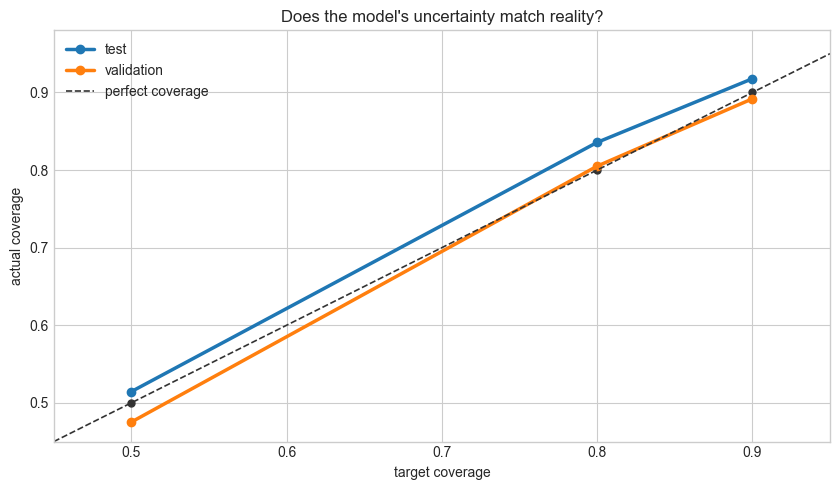

In [9]:
coverage_plot = coverage[coverage["split"].isin(["validation", "test"])].copy()
coverage_plot["level_label"] = (coverage_plot["expected_coverage"] * 100).round().astype(int).astype(str) + "%"

display(
    coverage_plot[
        ["split", "level_label", "expected_coverage", "actual_coverage", "coverage_error", "avg_interval_width", "n"]
    ].style.format(
        {
            "expected_coverage": "{:.1%}",
            "actual_coverage": "{:.1%}",
            "coverage_error": "{:+.1%}",
            "avg_interval_width": "{:.2f} F",
            "n": "{:,}",
        }
    )
)

fig, ax = plt.subplots(figsize=(8.5, 5))
for split_name, group in coverage_plot.groupby("split"):
    ax.plot(group["expected_coverage"], group["actual_coverage"], marker="o", linewidth=2.5, label=split_name)
for value in [0.5, 0.8, 0.9]:
    ax.scatter([value], [value], color="#333333", s=25)
ax.plot([0.45, 0.95], [0.45, 0.95], color="#333333", linestyle="--", linewidth=1.2, label="perfect coverage")
ax.set_xlim(0.45, 0.95)
ax.set_ylim(0.45, 0.98)
ax.set_xlabel("target coverage")
ax.set_ylabel("actual coverage")
ax.set_title("Does the model's uncertainty match reality?")
ax.legend()
plt.tight_layout()
plt.show()


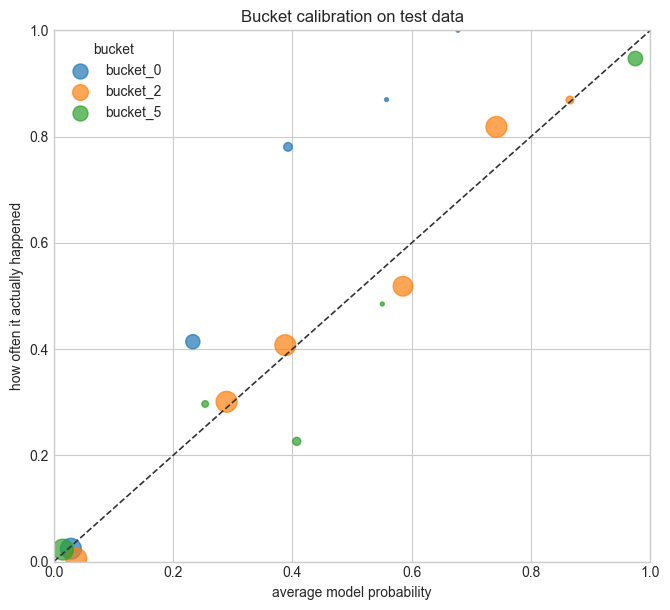

In [10]:
test_reliability = reliability[reliability["split"] == "test"].copy()
selected_buckets = ["market_bucket_0", "market_bucket_2", "market_bucket_5"]

fig, ax = plt.subplots(figsize=(6.8, 6.2))
for bucket in selected_buckets:
    data = test_reliability[test_reliability["bucket"] == bucket]
    if data.empty:
        continue
    size = np.clip(data["count"].to_numpy(dtype=float), 30, 900) / 4
    ax.scatter(
        data["mean_predicted_probability"],
        data["empirical_frequency"],
        s=size,
        alpha=0.7,
        label=bucket.replace("market_", ""),
    )
ax.plot([0, 1], [0, 1], color="#333333", linestyle="--", linewidth=1.2)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel("average model probability")
ax.set_ylabel("how often it actually happened")
ax.set_title("Bucket calibration on test data")
ax.legend(title="bucket")
plt.tight_layout()
plt.show()
